<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# ReAct: Crea agentes de IA de Razonamiento y acción con LangGraph

Eres un ingeniero de software con una misión: crear un agente de IA que no solo responda, sino que piense. En este laboratorio, te pondrás en la piel de un arquitecto de IA, diseñando un asistente inteligente capaz de resolver problemas complejos razonando y tomando acciones con propósito.

Utilizando el marco ReAct (Razonamiento + Acción), enseñarás a tu agente a pensar paso a paso, consultar herramientas como buscadores o calculadoras y adaptarse sobre la marcha. No se trata solo de encontrar respuestas, sino de cómo el agente llega a ellas.

Al finalizar el laboratorio, tu IA se enfrentará a un misterio que no se puede resolver solo con conocimiento. Necesitará lógica, ingenio y capacidad de acción, al igual que tú, el ingeniero que la creó.

## ¿Qué es ReAct?

**ReAct** significa **Razonamiento + Acción**. Es un marco que combina:

1. **Razonamiento**: El agente analiza los problemas paso a paso, manteniendo un diálogo interno sobre lo que necesita hacer.

2. **Acción**: El agente puede usar herramientas externas (buscadores, calculadoras, API) para recopilar información o realizar acciones.

3. **Observación**: El agente procesa los resultados de sus acciones y los incorpora a su razonamiento.

Esto crea un ciclo poderoso: **Pensar → Actuar → Observar → Pensar → Actuar → ...**

### *Por qué ReAct es Importante*

Los modelos de lenguaje tradicionales están limitados por la cantidad de datos de entrenamiento y no pueden acceder a información en tiempo real. Los agentes de ReAct superan esta limitación mediante:
- El acceso a información actualizada a través de búsquedas web.

- La realización de cálculos con herramientas especializadas.

- La división de problemas complejos en pasos manejables.

- La adaptación de su enfoque en función de los resultados intermedios.

## __Table of Contents__

<ol>
    <li>
        <a href="#Setting-up-the-Language-Model">Setting up the Language Model</a>
        <ol>
            <li><a href="#Initializing-the-AI-Model">Initializing the AI Model</a></li>
            <li><a href="#Creating-the-System-Prompt">Creating the System Prompt</a></li>
            <li><a href="#The-System-Prompt's-Role">The System Prompt's Role</a></li>
            <li><a href="#Binding-Tools-to-the-Model">Binding Tools to the Model</a></li>
            <li>
                <a href="#Understanding-Agent-State">Understanding Agent State</a>
                <ol>
                    <li><a href="#What-is-Agent-State?">What is Agent State?</a></li>
                    <li><a href="#Demonstrating-State-Management">Demonstrating State Management</a></li>
                </ol>
            </li>
            <li>
                <a href="#Manual-ReAct-Execution-(Understanding-the-Flow)">Manual ReAct Execution (Understanding the Flow)</a>
                <ol>
                    <li><a href="#Step-1:-Initial-Query-Processing">Step 1: Initial Query Processing</a></li>
                    <li><a href="#Step-2:-Tool-Execution">Step 2: Tool Execution</a></li>
                    <li><a href="#Step-3:-Processing-Results-and-Next-Action">Step 3: Processing Results and Next Action</a></li>
                    <li><a href="#Step-4:-Final-Response-Generation">Step 4: Final Response Generation</a></li>
                </ol>
            </li>
            <li>
                <a href="#Automating-ReAct-with-Graphs">Automating ReAct with Graphs</a>
                <ol>
                    <li><a href="#Why-Use-Graphs?">Why Use Graphs?</a></li>
                    <li><a href="#Building-the-Core-Functions">Building the Core Functions</a></li>
                    <li><a href="#Constructing-the-State-Graph">Constructing the State Graph</a></li>
                    <li><a href="#Visualizing-the-Graph">Visualizing the Graph</a></li>
                </ol>
            </li>
            <li>
                <a href="#Running-the-Complete-ReAct-Agent">Running the Complete ReAct Agent</a>
                <ol>
                    <li><a href="#Final-Execution">Final Execution</a></li>
                    <li><a href="#The-Complete-ReAct-Cycle">The Complete ReAct Cycle</a></li>
                </ol>
            </li>
        </ol>
    </li>
    <li>
        <a href="#Key-Takeaways">Key Takeaways</a>
        <ol>
            <li><a href="#What-Makes-ReAct-Powerful">What Makes ReAct Powerful</a></li>
            <li><a href="#Best-Practices">Best Practices</a></li>
        </ol>
    </li>
    <li>
        <a href="#Exercises">Exercises</a>
        <ol>
            <li><a href="#Exercise-1---Build-a-Calculator-Tool">Exercise 1 - Build a Calculator Tool</a></li>
            <li><a href="#Exercise-2---Create-a-News-Summary-Tool">Exercise 2 - Create a News Summary Tool</a></li>
        </ol>
    </li>
    <li><a href="#Testing-Your-Solutions">Testing Your Solutions</a></li>
    <li><a href="#Authors">Authors</a></li>
</ol>


## 1. Objetivos

Tras completar este laboratorio, podrás:

- Utilizar el marco de trabajo ReAct para resolver problemas de varios pasos con herramientas externas.

- Enseñar a un agente de IA a razonar paso a paso, tomar acciones y adaptarse según los resultados.

- Crear un asistente inteligente capaz de gestionar tareas que requieren lógica y el uso de herramientas.

## 2. Configuración e Instalación


Para este laboratorio, utilizaremos las siguientes bibliotecas:

- [`LangGraph`](https://www.langchain.com/langgraph): Un marco de trabajo para crear aplicaciones de IA con estado y de múltiples pasos mediante grafos.

- [`LangChain`](https://www.langchain.com/): Un conjunto de herramientas que proporciona herramientas y abstracciones para trabajar con modelos de lenguaje.

- [`LangChain-OpenAI`](https://python.langchain.com/docs/integrations/llms/openai/): Integración de OpenAI para LangChain.

- [`LangChain-Community`](https://python.langchain.com/api_reference/community/index.html): Herramientas e integraciones aportadas por la comunidad.

### *2.1. Instalación de las Bibliotecas Necesarias*

Las siguientes bibliotecas necesarias no están preinstaladas en el su entorno. Debe ejecutar la siguiente celda para instalarlas. Este paso puede tardar varios minutos, tenga paciencia.

```bash
pip install -r requirements.txt
```

### *2.2. Importación de las Bibliotecas Necesarias*

Importa aquí todas las bibliotecas necesarias:

In [4]:
from dotenv import load_dotenv

import json

from langchain_tavily import TavilySearch
from langchain.tools import tool


import warnings 
warnings.filterwarnings('ignore')

### *2.3. Entendiendo las Herramientas en ReAct*

Las herramientas son la parte "activa" de ReAct. Le otorgan al agente capacidades que van más allá de la simple generación de texto. Vamos a crear dos herramientas esenciales:

#### 2.3.1. Herramienta de búsqueda web

##### *2.3.1.1. Configuración de la clave API de Tavily Search*


Usaremos Tavily Search como nuestra herramienta de investigación externa. Puedes obtener una clave API en https://app.tavily.com/sign-in

**Aviso legal:** Al registrarte en Tavily, recibirás créditos gratuitos, más que suficientes para este proyecto. Si necesitas créditos adicionales para otros usos, puedes añadirlos bajo tu propia responsabilidad.

![image.png](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UjJx1-0vss4_3lwsUF8n0w/image.png)

Agrega en tu archivo `.env` la siguiente línea, reemplazando `YOUR_KEY_HERE` con tu clave API de Tavily:

```env
TAVILY_API_KEY=YOUR_KEY_HERE
```

In [ ]:
# Carga las variables de entorno desde el archivo .env.
load_dotenv()

True

In [5]:
# Inicializa la herramienta de búsqueda de Tavily.
busqueda = TavilySearch()

@tool
def herramienta_busqueda(consulta: str):
    """
    Busca información en la web utilizando la API de Tavily.

    :param consulta: La cadena de consulta de búsqueda
    :return: Resultados de búsqueda relacionados con la consulta
    """
    return busqueda.invoke(consulta)

##### *2.3.1.2. Teoría detrás de las herramientas de búsqueda web*

- Permiten la recuperación de información en tiempo real

- Superan la limitación del umbral de conocimiento de los modelos de lenguaje

- Devuelven datos estructurados que el agente puede procesar y analizar

##### *2.3.1.3. Pruebas de la herramienta de búsqueda*

In [8]:
herramienta_busqueda.invoke("¿Qué tiempo hace hoy en Tokio?")

{'query': '¿Qué tiempo hace hoy en Tokio?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.tiempo3.com/asia/japan/tokyo?page=today',
   'title': 'Tiempo para hoy en Tokio | Tiempo3.com',
   'content': 'Durante la mañana de hoy se espera una temperatura de 20°C en Tokio. La probabilidad de lluvias será del 0% y la velocidad del viento será de 4 Km/h.',
   'score': 0.898277,
   'raw_content': None},
  {'url': 'https://es.weatherandradar.com/tiempo/tokio/14249651',
   'title': 'Tiempo actual en Tokio',
   'content': 'Hoy hasta la tarde-noche estará muy soleado. La temperatura actual es de 80 grados y más tarde descenderá hasta 63 grados.',
   'score': 0.8757978,
   'raw_content': None},
  {'url': 'https://www.accuweather.com/es/jp/tokyo/226396/current-weather/226396',
   'title': 'Tiempo actual en Tokio, Tokio, Japón - AccuWeather',
   'content': 'El tiempo ahora. 23:35. 69°F. Mayormente despejado.',
   'score': 0.8573986,
   'raw_content':

Esta prueba demuestra cómo el agente puede acceder a información actual que no estaba disponible durante el entrenamiento.

#### 2.3.2. Herramienta de recomendación de ropa

In [9]:
@tool
def recomendacion_ropa(clima: str) -> str:
    """
    Devuelve una recomendación de vestimenta basada en la descripción del clima proporcionada.
    
    Esta función analiza la cadena de entrada en busca de palabras clave o indicadores de temperatura específicos
    (p. ej., "nieve", "helado", "lluvia", "29 °C") para sugerir la vestimenta adecuada. Maneja condiciones climáticas 
    comunes como nieve, lluvia, calor y frío, proporcionando recomendaciones de vestimenta sencillas y prácticas.

    :param clima: Una breve descripción del clima (p. ej., "Nublado, 18 °C")
    :return: Una cadena con recomendaciones de vestimenta adecuadas para el clima
    """

    clima = clima.lower()
    if "nieve" in clima or "helado" in clima:
        return "Use un abrigo grueso, guantes y botas."
    
    elif "lluvia" in clima or "humedo" in clima:
        return "Lleva un impermeable y zapatos impermeables."
    
    elif "calor" in clima or "85" in clima:
        return "Se recomienda llevar camiseta, pantalones cortos y protector solar."
    
    elif "frío" in clima or "50" in clima:
        return "Se recomienda llevar una chaqueta caliente o suéter."
    
    else:
        return "Una chaqueta ligera debería estar bien."

**Por qué es importante esta herramienta:**

- Demuestra el razonamiento específico del dominio

- Muestra cómo las herramientas pueden procesar e interpretar datos de otras herramientas

- Ilustra la capacidad de composición de los sistemas ReAct

#### 2.3.3. Creación del registro de herramientas

In [10]:
herramientas = [herramienta_busqueda, recomendacion_ropa]

herramientas_por_nombre = { tool.name:tool for tool in herramientas}

Este registro permite al agente seleccionar e invocar dinámicamente la herramienta adecuada según la tarea en cuestión.

## 3. Configuración del Modelo de Lenguaje

### *3.1. Inicialización del Modelo de IA*

In [12]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

llm = ChatOpenAI(model= "gpt-4o-mini")

Utilizamos GPT-4o-mini como motor de razonamiento. Este modelo realizará las siguientes funciones:
- Analizar las consultas del usuario

- Decidir qué herramientas utilizar

- Procesar los resultados de las herramientas

- Generar las respuestas finales

### *3.2. Creación del Mensaje del Sistema*

In [24]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage,SystemMessage

prompt_razonamiento = ChatPromptTemplate.from_messages([
    ("system", """Eres un asistente de IA útil que piensa paso a paso y utiliza herramientas cuando es necesario.
    Al responder a consultas:
    1. Primero, piensa qué información necesitas.
    2. Utiliza las herramientas disponibles si necesitas datos actualizados o funcionalidades específicas.
    3. Proporciona respuestas claras y útiles basadas en tu razonamiento y los resultados de las herramientas.

    Explica siempre tu proceso de pensamiento para que los usuarios comprendan tu enfoque.
"""),
    MessagesPlaceholder(variable_name= "bloc_notas")
])

**Función del Sistema de Indicaciones:**
- Define el comportamiento y la personalidad del agente

- Establece el patrón de razonamiento (pensar → actuar → observar)

- Fomenta la transparencia en el proceso de toma de decisiones

### *3.3. Herramientas de Vinculación con el Modelo*

In [25]:
cadena_modelo_razonamiento = prompt_razonamiento | llm.bind_tools(herramientas)

Esto crea un modelo que puede:
- Entender cuándo usar las herramientas

- Generar llamadas a herramientas con el formato adecuado

- Procesar los resultados de las herramientas en contexto

## 4. Entendiendo el Estado del Agente

### *4.1. ¿Qué es el Estado del Agente?*

En ReAct, la gestión del estado es crucial, ya que el agente debe mantener el contexto a lo largo de múltiples pasos de razonamiento y acción.

In [37]:
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from typing import Annotated, Sequence, TypedDict

class EstadoAgente(TypedDict):
    """El estado del agente."""
    # add_messages es un reductor que acumula mensajes a lo largo del tiempo, permitiendo al agente mantener un historial de su razonamiento y acciones.
    # Ver https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers
    mensajes: Annotated[Sequence[BaseMessage], add_messages]

**Conceptos clave:**
- **Estado**: Contiene el historial y el contexto de la conversación.

- **Reductor**: `add_messages` gestiona automáticamente la adición de nuevos mensajes a la conversación.

- **Seguridad de tipos**: TypedDict garantiza que nuestra estructura de estado esté bien definida.

In [42]:
# Ejemplo de uso del estado del agente.
estado: EstadoAgente = {"mensajes": []}

# Agregar un mensaje usando el reductor correctamente.
estado["mensajes"] = add_messages(estado["mensajes"], [HumanMessage(content= "Hola")])
print("Después del saludo:", estado["mensajes"])

# Agregar otro mensaje.
estado["mensajes"] = add_messages(estado["mensajes"], [HumanMessage(content="¿Cuál es el clima en NYC?")])
print("Después de la pregunta:", estado["mensajes"])

Después del saludo: [HumanMessage(content='Hola', additional_kwargs={}, response_metadata={}, id='5a6c4387-566e-46ec-9ea5-0eb140c989c2')]
Después de la pregunta: [HumanMessage(content='Hola', additional_kwargs={}, response_metadata={}, id='5a6c4387-566e-46ec-9ea5-0eb140c989c2'), HumanMessage(content='¿Cuál es el clima en NYC?', additional_kwargs={}, response_metadata={}, id='f055ef3c-a3dc-4340-9b24-f1c45186db17')]


Esto demuestra cómo el estado acumula contexto a lo largo de la conversación.

## 5. Ejecución Manual de ReAct (Comprensión del Flujo)

Antes de crear el gráfico automatizado, analicemos manualmente un ciclo de ReAct para comprender su funcionamiento:

### *5.1. Paso 1: Procesamiento Inicial de la Consulta*

In [43]:
estado_ejemplo: EstadoAgente = {
    "mensajes": [HumanMessage( "¿Qué tiempo hace en Zúrich y qué ropa debo llevar según la temperatura?")]}

respuesta = cadena_modelo_razonamiento.invoke({"bloc_notas": estado_ejemplo["mensajes"]})

estado_ejemplo["mensajes"] = add_messages(estado_ejemplo["mensajes"], [respuesta])

In [44]:
estado_ejemplo

{'mensajes': [HumanMessage(content='¿Qué tiempo hace en Zúrich y qué ropa debo llevar según la temperatura?', additional_kwargs={}, response_metadata={}, id='a9cdc0f2-58dc-4cff-a1f8-f115b2f0c475'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 335, 'total_tokens': 359, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2421cf5c7d', 'id': 'chatcmpl-DghNWR6wUM3urjTPYBSyEqorsK5v6', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e38c4-f990-7143-ac74-c5b6aaa75f97-0', tool_calls=[{'name': 'herramienta_busqueda', 'args': {'consulta': 'clima actual en Zúrich'}, 'id': 'call_ObdDhdAbw3u3Xdku2qUNlHmW', 'type': 'tool_c

**¿Qué sucede aquí?**
1. El usuario formula una pregunta compleja que requiere datos actualizados.

2. El modelo analiza la consulta y determina que necesita buscar información meteorológica.

3. El modelo genera una solicitud a la herramienta para realizar la búsqueda.

### *5.2. Paso 2: Ejecución de la Herramienta*

In [45]:
llamar_herramienta = respuesta.tool_calls[-1]
print("Llamar herramienta:", llamar_herramienta)

resultado_herramienta = herramientas_por_nombre[llamar_herramienta["name"]].invoke(llamar_herramienta["args"])
print("Resultado herramienta:", resultado_herramienta['results'][0]['title'])

tool_message = ToolMessage(
    content= json.dumps(resultado_herramienta['results']),
    name= llamar_herramienta["name"],
    tool_call_id= llamar_herramienta["id"]
)
estado_ejemplo["mensajes"] = add_messages(estado_ejemplo["mensajes"], [tool_message])

Llamar herramienta: {'name': 'herramienta_busqueda', 'args': {'consulta': 'clima actual en Zúrich'}, 'id': 'call_ObdDhdAbw3u3Xdku2qUNlHmW', 'type': 'tool_call'}
Resultado herramienta: Clima en Zúrich hoy y pronóstico del tiempo a 14 días


In [46]:
estado_ejemplo

{'mensajes': [HumanMessage(content='¿Qué tiempo hace en Zúrich y qué ropa debo llevar según la temperatura?', additional_kwargs={}, response_metadata={}, id='a9cdc0f2-58dc-4cff-a1f8-f115b2f0c475'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 335, 'total_tokens': 359, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2421cf5c7d', 'id': 'chatcmpl-DghNWR6wUM3urjTPYBSyEqorsK5v6', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e38c4-f990-7143-ac74-c5b6aaa75f97-0', tool_calls=[{'name': 'herramienta_busqueda', 'args': {'consulta': 'clima actual en Zúrich'}, 'id': 'call_ObdDhdAbw3u3Xdku2qUNlHmW', 'type': 'tool_c

**Qué sucede aquí**
1. Extraer la llamada a la herramienta de la respuesta del modelo.

2. Ejecutar la herramienta con los argumentos especificados.

3. Crear un ToolMessage con los resultados.

4. Agregar el resultado de la herramienta al estado de la conversación.

### *5.3. Paso 3: Procesamiento de Resultados y Siguiente Acción*

In [47]:
respuesta = cadena_modelo_razonamiento.invoke({"bloc_notas": estado_ejemplo["mensajes"]})
estado_ejemplo['mensajes'] = add_messages(estado_ejemplo['mensajes'], [respuesta])

# Comprobar si el modelo quiere usar otra herramienta
if respuesta.tool_calls:
    llamar_herramienta = respuesta.tool_calls[0]
    tool_result = herramientas_por_nombre[llamar_herramienta["name"]].invoke(llamar_herramienta["args"])
    tool_message = ToolMessage(
        content= json.dumps(tool_result),
        name= llamar_herramienta["name"],
        tool_call_id= llamar_herramienta["id"]
    )
    estado_ejemplo['mensajes'] = add_messages(estado_ejemplo['mensajes'], [tool_message])

In [48]:
estado_ejemplo

{'mensajes': [HumanMessage(content='¿Qué tiempo hace en Zúrich y qué ropa debo llevar según la temperatura?', additional_kwargs={}, response_metadata={}, id='a9cdc0f2-58dc-4cff-a1f8-f115b2f0c475'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 335, 'total_tokens': 359, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2421cf5c7d', 'id': 'chatcmpl-DghNWR6wUM3urjTPYBSyEqorsK5v6', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e38c4-f990-7143-ac74-c5b6aaa75f97-0', tool_calls=[{'name': 'herramienta_busqueda', 'args': {'consulta': 'clima actual en Zúrich'}, 'id': 'call_ObdDhdAbw3u3Xdku2qUNlHmW', 'type': 'tool_c

**¿Qué sucede aquí?**
1. El modelo procesa los resultados de la búsqueda.

2. Determina que necesita usar la herramienta de recomendación de ropa.

3. Extrae información meteorológica y llama a la herramienta de recomendación de ropa.

4. Recibe recomendaciones de ropa basadas en los datos meteorológicos.

### *5.4. Paso 4: Generación de la Respuesta Final*

In [49]:
respuesta = cadena_modelo_razonamiento.invoke({"bloc_notas": estado_ejemplo["mensajes"]})

print("Respuesta final generada:", respuesta.content is not None)
print("Más herramientas necesarias:", bool(respuesta.tool_calls))

Respuesta final generada: True
Más herramientas necesarias: False


**¿Qué sucede aquí?**
1. El modelo cuenta con toda la información necesaria.

2. Sintetiza datos meteorológicos y recomendaciones de vestimenta.

3. Genera una respuesta completa para el usuario.

4. No se requieren más llamadas a herramientas: el ciclo de razonamiento ha finalizado.

## 6. Automatización de ReAct con Grafos

### *6.1. ¿Por qué Usar Grafos?*

La ejecución manual de ReAct es didáctica, pero poco práctica para aplicaciones reales. LangGraph automatiza este proceso con una máquina de estados que gestiona automáticamente el bucle de razonamiento.

### *6.2. Creación de las Funciones Principales*

#### 6.2.1. Nodo de ejecución de la herramienta

In [50]:
def nodo_herramienta(estado: EstadoAgente):
    """Ejecutar todas las llamadas a herramientas desde el último mensaje en el estado."""

    salidas = []
    for llamar_herramienta in estado["mensajes"][-1].tool_calls:
        tool_result = herramientas_por_nombre[llamar_herramienta["name"]].invoke(llamar_herramienta["args"])
        salidas.append(
            ToolMessage(
                content= json.dumps(tool_result),
                name= llamar_herramienta["name"],
                tool_call_id= llamar_herramienta["id"],
            )
        )
    return {"mensajes": salidas}

**Función**
- Ejecutar automáticamente todas las llamadas a herramientas del modelo

- Gestionar múltiples llamadas simultáneas a herramientas

- Devolver mensajes de herramientas con el formato correcto

#### 6.2.2. Nodo de invocación del modelo

In [51]:
def llamar_modelo(estado: EstadoAgente):
    """Invoca el modelo con el estado actual de la conversación."""
    respuesta = cadena_modelo_razonamiento.invoke({"bloc_notas": estado["mensajes"]})
    return {"mensajes": [respuesta]}

**Propósito de la función**
- Llamar al modelo habilitado para ReAct

- Pasar el contexto completo de la conversación

- Devolver la respuesta del modelo (que puede incluir llamadas a herramientas)

#### 6.2.3. Lógica de decisión

In [53]:
def deberia_continuar(estado: EstadoAgente):
    """Determinar si se debe continuar utilizando la herramienta o finalizar la conversación."""
    mensajes = estado["mensajes"]
    ultima_mensaje = mensajes[-1]
    # Si no hay llamada a herramienta, entonces terminamos.
    if not ultima_mensaje.tool_calls:
        return "fin"
    # De lo contrario, si hay, continuamos.
    else:
        return "continuar"

**Propósito de la función**
- Implementar la lógica del flujo de control

- Decidir si el agente necesita usar más herramientas

- Dirigir la conversación hacia la ejecución de herramientas o hacia su finalización

### 6.2.4. Construcción del grafo de estados

In [54]:
from langgraph.graph import StateGraph, END

# Definir el grafo de estados para el agente de razonamiento-acción.
flujo_trabajo = StateGraph(EstadoAgente)

# Defina los dos nodos entre los que alternaremos.
flujo_trabajo.add_node("agente", llamar_modelo)
flujo_trabajo.add_node("herramientas", nodo_herramienta)

# Agregar bordes para definir el flujo de trabajo.
flujo_trabajo.add_edge("herramientas", "agente")  # Después de ejecutar herramientas, volvemos al agente para que procese los resultados.

# Agregar bordes condicionales para decidir si el agente necesita usar más herramientas o si ha terminado.
flujo_trabajo.add_conditional_edges(
    "agente",
    deberia_continuar,
    {
        "continuar": "herramientas",  # Si el modelo indica que necesita usar más herramientas, vamos al nodo de herramientas.
        "fin": END,          # Si el modelo indica que ha terminado, vamos al nodo de fin.
    },
)

# Establecer el punto de entrada del grafo en el nodo del agente.
flujo_trabajo.set_entry_point("agente")

# Compilar el grafo para prepararlo para la ejecución.
graph = flujo_trabajo.compile()

**Explicación de la estructura del grafo**
1. **Nodo del agente**: Donde se produce el razonamiento y se generan las llamadas a las herramientas.

2. **Nodo de herramientas**: Donde se ejecuta la herramienta.

3. **Arista condicional**: Determina si se debe continuar o finalizar.

4. **Punto de entrada**: La conversación siempre comienza con el razonamiento del agente.

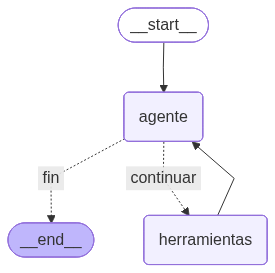

In [55]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # Si la visualización falla, simplemente pasamos sin mostrar la imagen.
    pass

Esta visualización muestra el flujo: Agente → Decisión → Herramientas → Agente → Decisión → Fin

## 7. Ejecución del Agente ReAct Completo

### *7.1. Ejecución Final*

In [56]:
def flujo_impresion(stream):
    """Función auxiliar para formatear el flujo de forma adecuada."""
    for s in stream:
        ultimo_mensaje = s["mensajes"][-1]
        if isinstance(ultimo_mensaje, tuple):
            print(ultimo_mensaje)
        else:
            ultimo_mensaje.pretty_print()

entradas = {"mensajes": [HumanMessage(content= "¿Qué tiempo hace en Zúrich y qué ropa debo llevar según la temperatura?")]}

flujo_impresion(graph.stream(entradas, stream_mode= "values"))

================================ Human Message =================================

¿Qué tiempo hace en Zúrich y qué ropa debo llevar según la temperatura?
================================== Ai Message ==================================
Tool Calls:
  herramienta_busqueda (call_KrOm9EAkzBglXLKTGxLY4Nly)
 Call ID: call_KrOm9EAkzBglXLKTGxLY4Nly
  Args:
    consulta: tiempo actual en Zúrich
================================= Tool Message =================================
Name: herramienta_busqueda

{"query": "tiempo actual en Z\u00farich", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.tiempo3.com/europe/switzerland/zurich?page=today", "title": "Tiempo para hoy en Z\u00farich | Tiempo3.com", "content": "# Tiempo para hoy en Z\u00farich. Pron\u00f3stico del tiempo para hoy en Z\u00farich (lunes 18 de mayo del 2026). | Probabilidad de lluvia | 0% | 0% | 0% | 0% | 100% | 100% | 0% | 79% |. \u00bfC\u00f3mo ser\u00e1 el tiempo para hoy en Z\u00farich? L

**Qué verás**
1. **Razonamiento inicial**: El agente analiza la consulta.

2. **Llamada a la herramienta 1**: Busca el clima de Zúrich.

3. **Procesamiento de resultados de la herramienta**: El agente examina los datos meteorológicos.

4. **Llamada a la herramienta 2**: Obtiene recomendaciones de ropa.

5. **Síntesis final**: El agente combina toda la información para ofrecer una respuesta útil.

### *7.2. El Ciclo Completo de ReAct*

La ejecución final demuestra el patrón completo de ReAct:

1. **Razonamiento**: "Necesito datos meteorológicos actuales de Zúrich".

2. **Acción**: Se llama a la herramienta de búsqueda ("Tiempo en Zúrich hoy").

3. **Observación**: Se procesan los resultados de la búsqueda y se extrae la temperatura.

4. **Razonamiento**: "Ahora necesito recomendaciones de ropa para esta temperatura".

5. **Acción**: Se llama a la función de recomendación de ropa ("temperatura obtenida en la búsqueda").

6. **Observación**: Se obtienen sugerencias de ropa.

7. **Razonamiento**: "Ahora puedo proporcionar una respuesta completa".

8. **Respuesta final**: Se sintetiza la información meteorológica y las recomendaciones de ropa.

## 8. Conclusiones Clave

### *8.1. ¿Qué Hace que ReAct sea tan Potente?*

1. **Transparencia**: Puedes ver el proceso de razonamiento del agente.

2. **Adaptabilidad**: El agente puede gestionar resultados inesperados y cambiar de rumbo.

3. **Extensibilidad**: Es fácil añadir nuevas herramientas y funcionalidades.

4. **Fiabilidad**: El enfoque estructurado reduce las interpretaciones erróneas y mejora la precisión.

### *8.2. Mejores Prácticas*

1. **Diseño de herramientas**: Cree herramientas enfocadas y confiables.

2. **Gestión de errores**: Planifique para posibles fallos de las herramientas y resultados inesperados.

3. **Gestión de contexto**: Mantenga el estado manejable y relevante.

4. **Experiencia de usuario**: Proporcione información clara sobre las acciones del agente.

El marco ReAct representa un avance significativo hacia agentes de IA más capaces y confiables, que pueden razonar sobre problemas complejos y tomar decisiones relevantes en el mundo real.

Copyright © IBM Corporation. All rights reserved.
